In [31]:
# importing the libraries i will need for the machine learning models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_predict


In [7]:
# loaded the iris data from scikit learn datasets
iris=load_iris()

In [9]:
# turned the numpy array into a pandas dataframe
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [11]:
# added the target column to thhe df
df["Species"]=iris.target

In [15]:
# Identifies the unique values in target column 
df["Species"].unique()

array([np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')],
      dtype=object)

In [14]:
# loaded the target variable into a dictionary and introduced the column names for the target column 
df["Species"]=df["Species"].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
# Splitting our data into X,y
X=df.drop(columns=["Species"])
y=df["Species"]

In [17]:
# Shape of the X data
X.shape

(150, 4)

In [18]:
# shape of the y data
y.shape

(150,)

In [20]:
# called our models
model_nb=GaussianNB()
model_lr=LogisticRegression(max_iter=1000)
model_tree=DecisionTreeClassifier(max_depth=5)

In [21]:
# cross validation
cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)

In [23]:
# Evaluating each model
score_nb=cross_val_score(model_nb,X,y,cv=cv,scoring="accuracy")
score_lr=cross_val_score(model_lr,X,y,cv=cv,scoring="accuracy")
score_tree=cross_val_score(model_tree,X,y,cv=cv,scoring="accuracy")

In [32]:
# making predictions on all the models 
y_pred_nb=cross_val_predict(model_nb,X,y,cv=cv)
y_pred_lr=cross_val_predict(model_lr,X,y,cv=cv)
y_pred_tree=cross_val_predict(model_tree,X,y,cv=cv)

In [36]:
print("\nNaive bayes first 10 predictions:",y_pred_nb[:10])
print("Logistic regression first 10 predictions:",y_pred_lr[:10])
print("Decision tree first 10 predections:",y_pred_tree[:10])


Naive bayes first 10 predictions: ['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa']
Logistic regression first 10 predictions: [np.str_('setosa') np.str_('setosa') np.str_('setosa') np.str_('setosa')
 np.str_('setosa') np.str_('setosa') np.str_('setosa') np.str_('setosa')
 np.str_('setosa') np.str_('setosa')]
Decision tree first 10 predections: [np.str_('setosa') np.str_('setosa') np.str_('setosa') np.str_('setosa')
 np.str_('setosa') np.str_('setosa') np.str_('setosa') np.str_('setosa')
 np.str_('setosa') np.str_('setosa')]


In [44]:
#[str(iris.target_names[x]) for x in y_pred_lr]
#[str(iris.target_names[x]) for x in y_pred_tree]
pred_actual=pd.DataFrame({"Actual":y,"Naive bayes":y_pred_nb,"Logistic regression":y_pred_lr,"Decision tree":y_pred_tree})
pred_actual.head(30)

,Actual,Naive bayes,Logistic regression,Decision tree
0,setosa,setosa,setosa,setosa
1,setosa,setosa,setosa,setosa
2,setosa,setosa,setosa,setosa
3,setosa,setosa,setosa,setosa
4,setosa,setosa,setosa,setosa
5,setosa,setosa,setosa,setosa
6,setosa,setosa,setosa,setosa
7,setosa,setosa,setosa,setosa
8,setosa,setosa,setosa,setosa
9,setosa,setosa,setosa,setosa


In [ ]:
if pred_actual["Actual"]=pred_actual["Naive bayes"]=pred_actual["Logistic regression"]=pred_actual["Decision tree"]:
    df["

In [26]:
# printing the mean of the cross validation score for each model
print("\nNaive Bayes accuracy:",score_nb.mean())
print("Logistic Regression accuracy:",score_lr.mean())
print("Decision Tree accuracy:",score_tree.mean())


Naive Bayes accuracy: 0.9533333333333334
Logistic Regression accuracy: 0.9666666666666668
Decision Tree accuracy: 0.9333333333333333


In [53]:
from sklearn.metrics import confusion_matrix
cm_nb=confusion_matrix(y,y_pred_nb)
cm_lr=confusion_matrix(y,y_pred_lr)
cm_tree=confusion_matrix(y,y_pred_tree)
print("Naive bayes confusion_matrix:")
print(cm_nb)
print("Logistic regression confusion matrix:")
print(cm_lr)
print("Decision tree confusion matrix:")
print(cm_tree)

Naive bayes confusion_matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  4 46]]
Logistic regression confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  2 48]]
Decision tree confusion matrix:
[[50  0  0]
 [ 0 46  4]
 [ 0  6 44]]


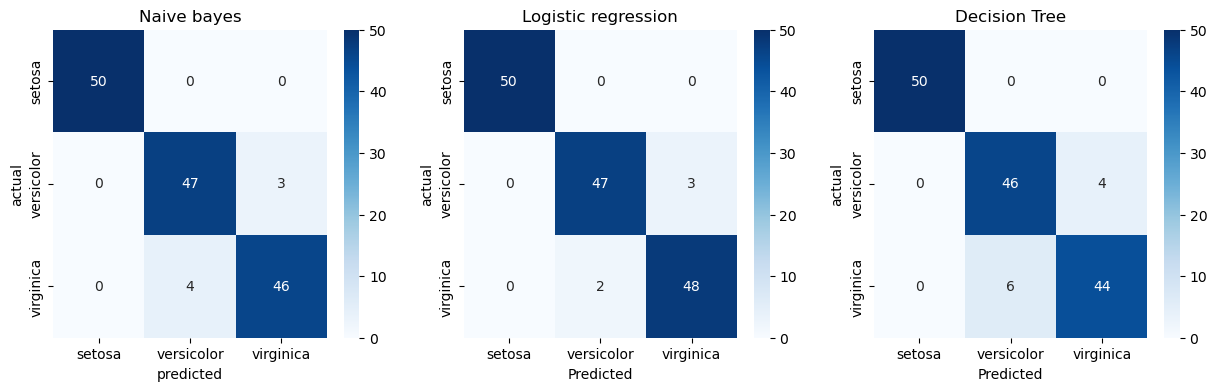

In [61]:
# plotting the confusion matrix plots to visually see how the models performed
models=[cm_nb,cm_lr,cm_tree]
titles=["Naive bayes","Logistic regression","Decision tree"]

# for plot 1,naive bayes plot
fig,axes=plt.subplots(1,3,figsize=(15,4))
sns.heatmap(cm_nb,annot=True,fmt='d',cmap='Blues',
           xticklabels=iris.target_names,
            yticklabels=iris.target_names,ax=axes[0])
axes[0].set(title="Naive bayes",xlabel="predicted",ylabel="actual")

# for plot 2,logistic regression plot
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Blues',
           xticklabels=iris.target_names,
           yticklabels=iris.target_names,
            ax=axes[1])
axes[1].set(title="Logistic regression",xlabel="Predicted",ylabel="actual")

# for plot 3,decison tree classfiers plot
sns.heatmap(cm_tree,annot=True,fmt='d',cmap='Blues',
           xticklabels=iris.target_names,yticklabels=iris.target_names,ax=axes[2])
axes[2].set(title="Decision Tree",xlabel="Predicted",ylabel="actual")
plt.show()


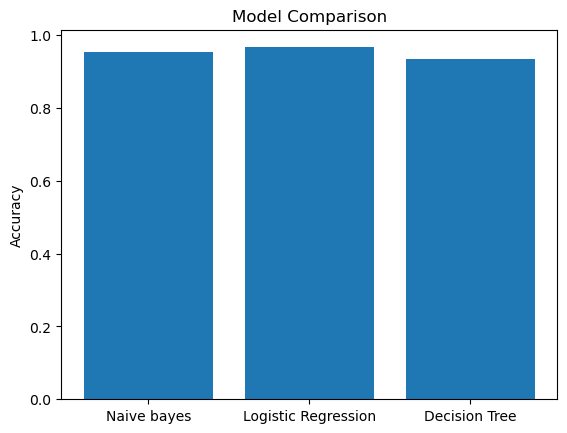

In [29]:
# comparing the results in a graph
models=["Naive bayes","Logistic Regression","Decision Tree"]
scores=[score_nb.mean(),score_lr.mean(),score_tree.mean()]
plt.bar(models,scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()